![New York City schoolbus](schoolbus.jpg)

Photo by [Jannis Lucas](https://unsplash.com/@jannis_lucas) on [Unsplash](https://unsplash.com).
<br>

Every year, American high school students take SATs, which are standardized tests intended to measure literacy, numeracy, and writing skills. There are three sections - reading, math, and writing, each with a **maximum score of 800 points**. These tests are extremely important for students and colleges, as they play a pivotal role in the admissions process.

Analyzing the performance of schools is important for a variety of stakeholders, including policy and education professionals, researchers, government, and even parents considering which school their children should attend. 

You have been provided with a dataset called `schools.csv`, which is previewed below.

You have been tasked with answering three key questions about New York City (NYC) public school SAT performance.

                                           school_name  average_math
88                              Stuyvesant High School           754
170                       Bronx High School of Science           714
93                 Staten Island Technical High School           711
365  Queens High School for the Sciences at York Co...           701
68   High School for Mathematics, Science, and Engi...           683
280                     Brooklyn Technical High School           682
333                        Townsend Harris High School           680
174  High School of American Studies at Lehman College           669
0    New Explorations into Science, Technology and ...           657
45                       Eleanor Roosevelt High School           641
                                           school_name  total_SAT
88                              Stuyvesant High School       2144
170                       Bronx High School of Science       2041
93                 Staten Island Technical 

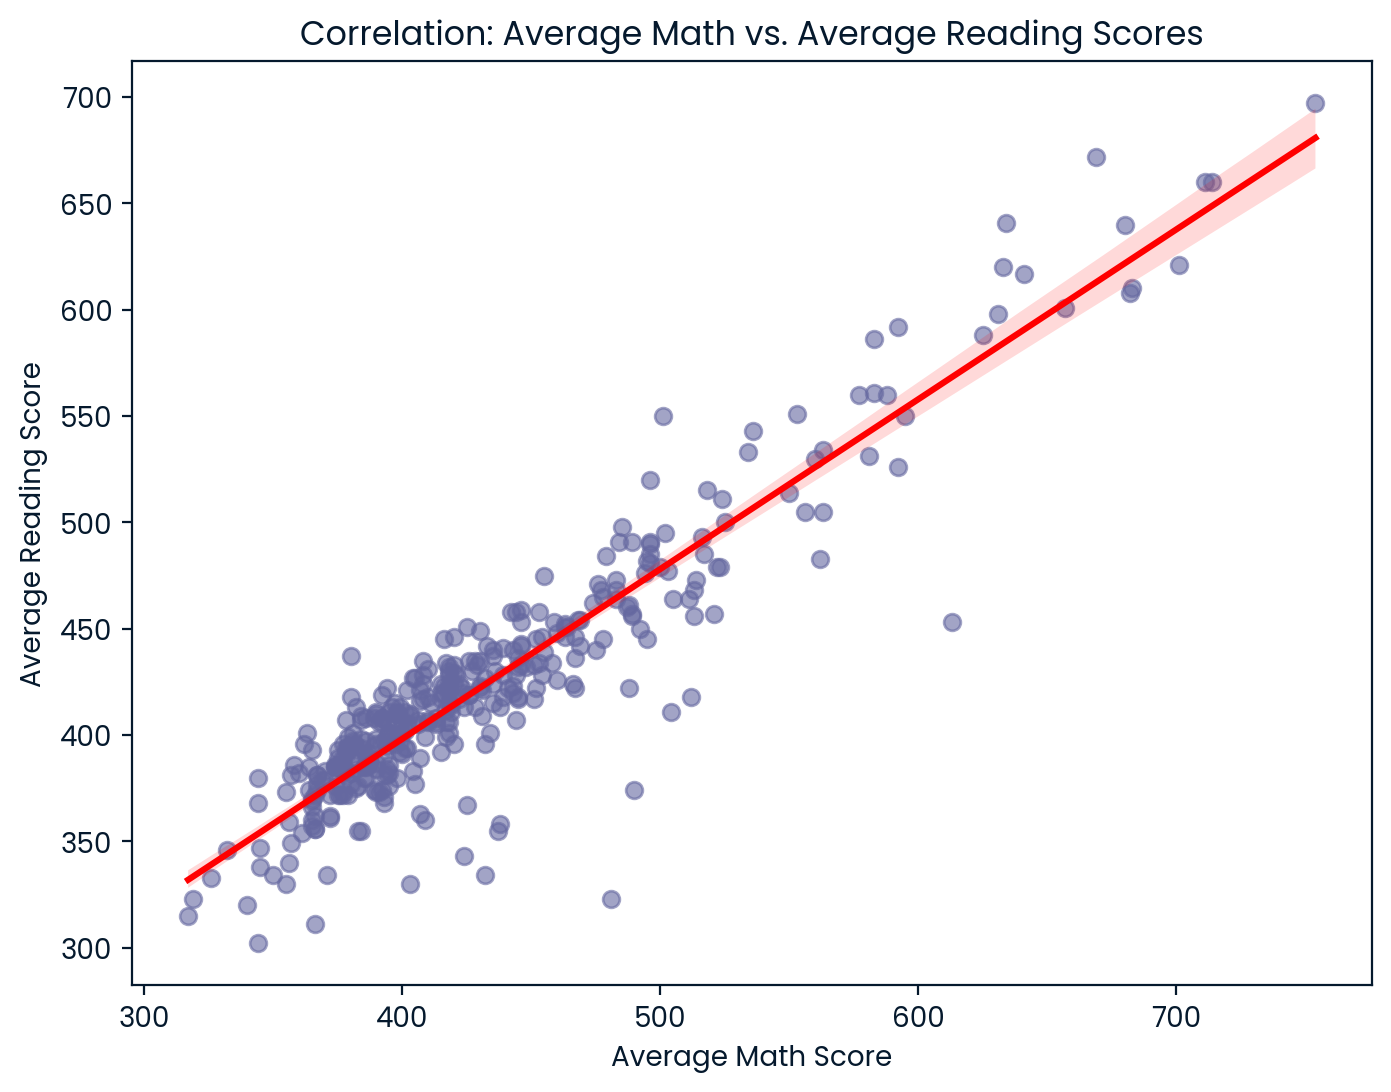

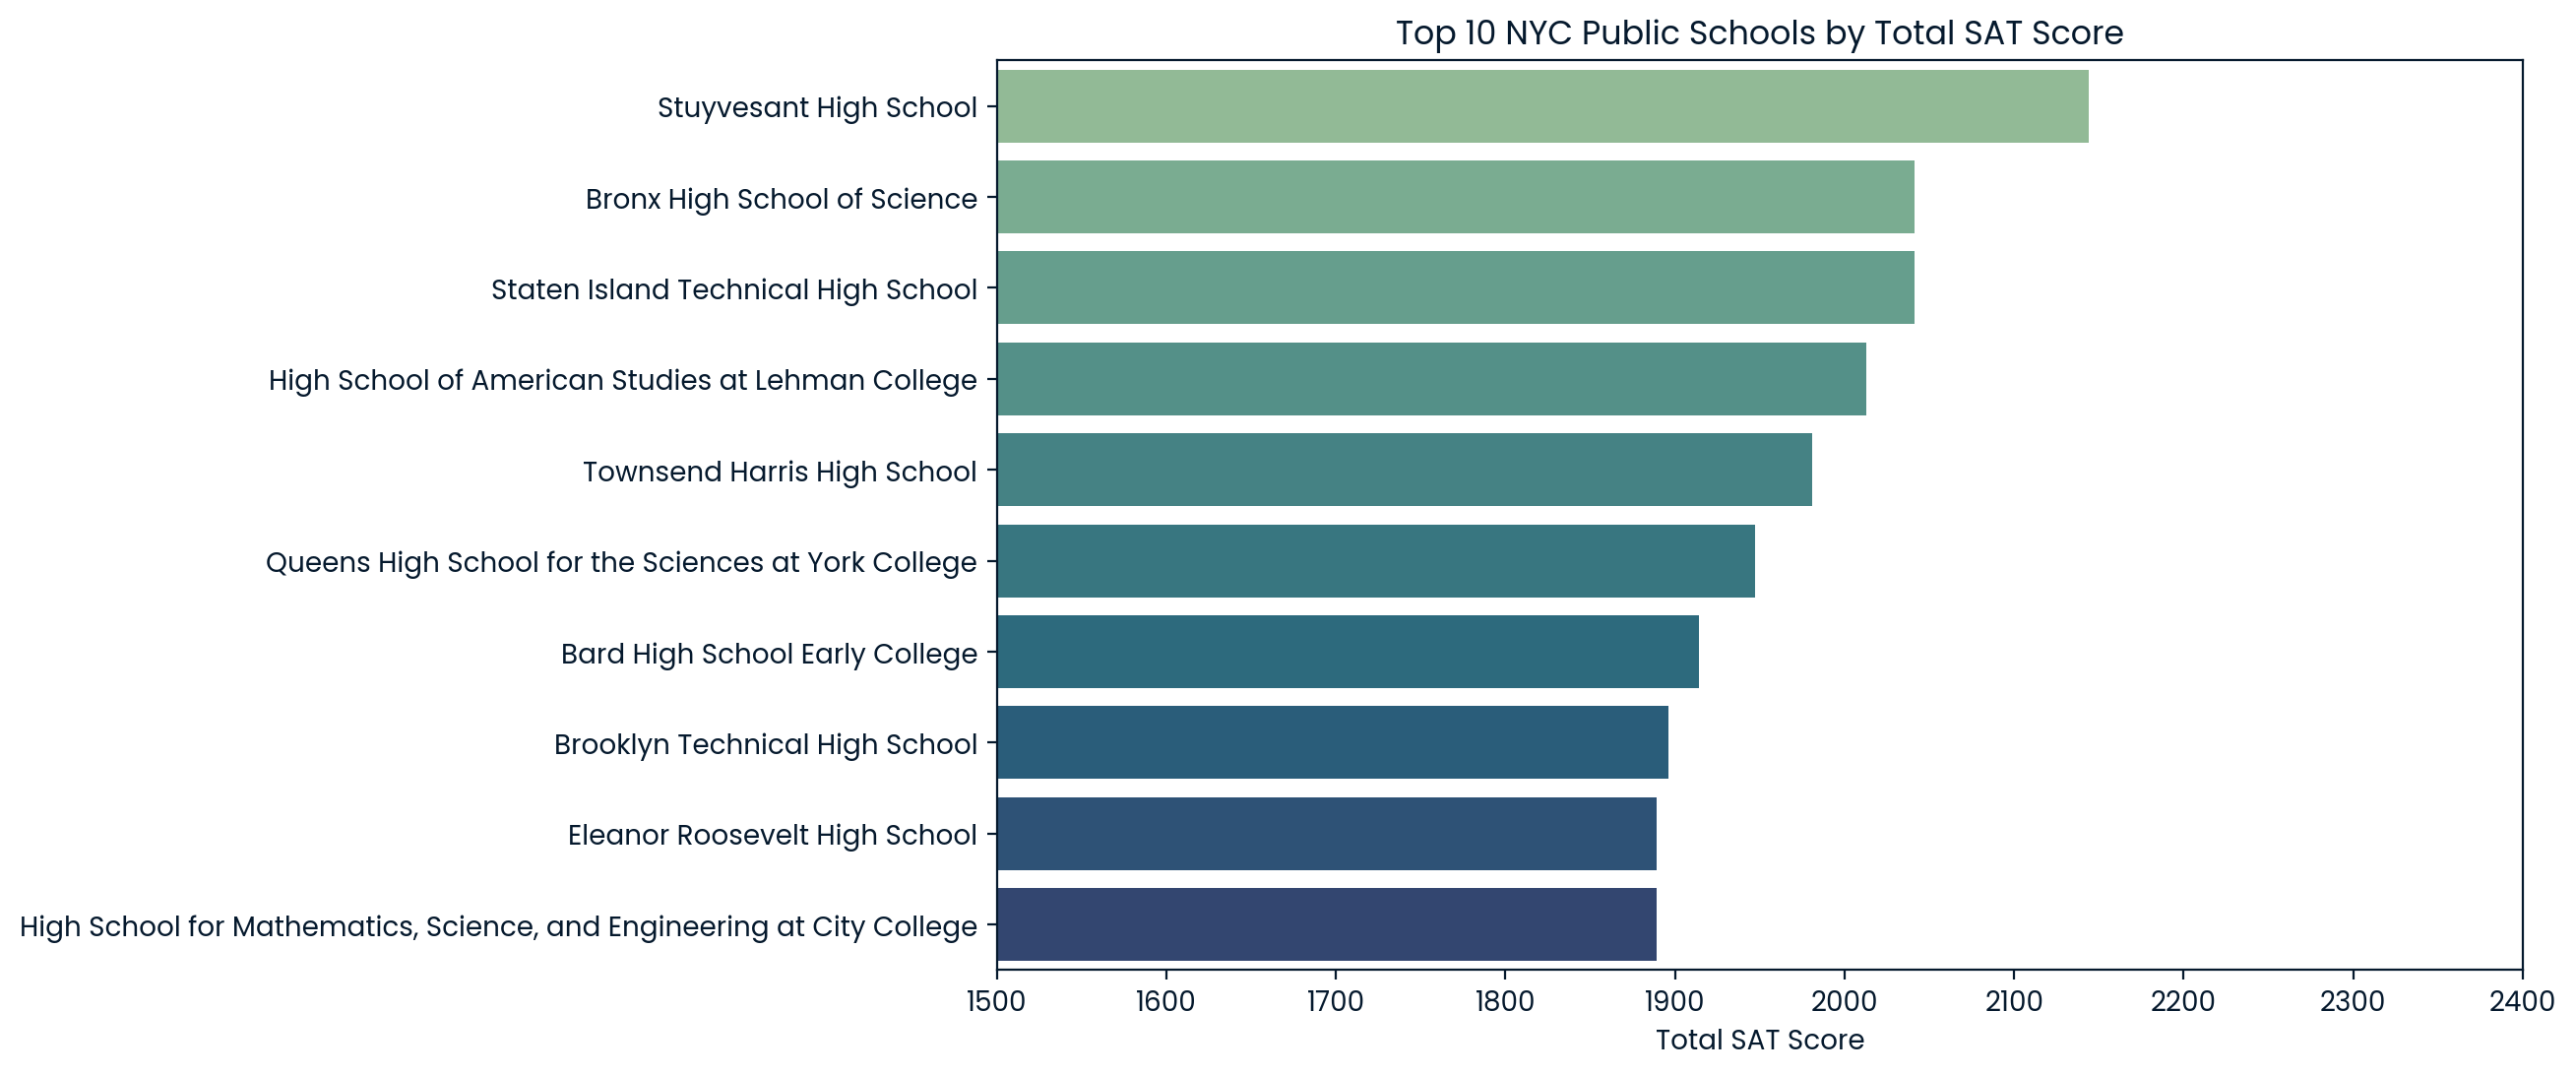

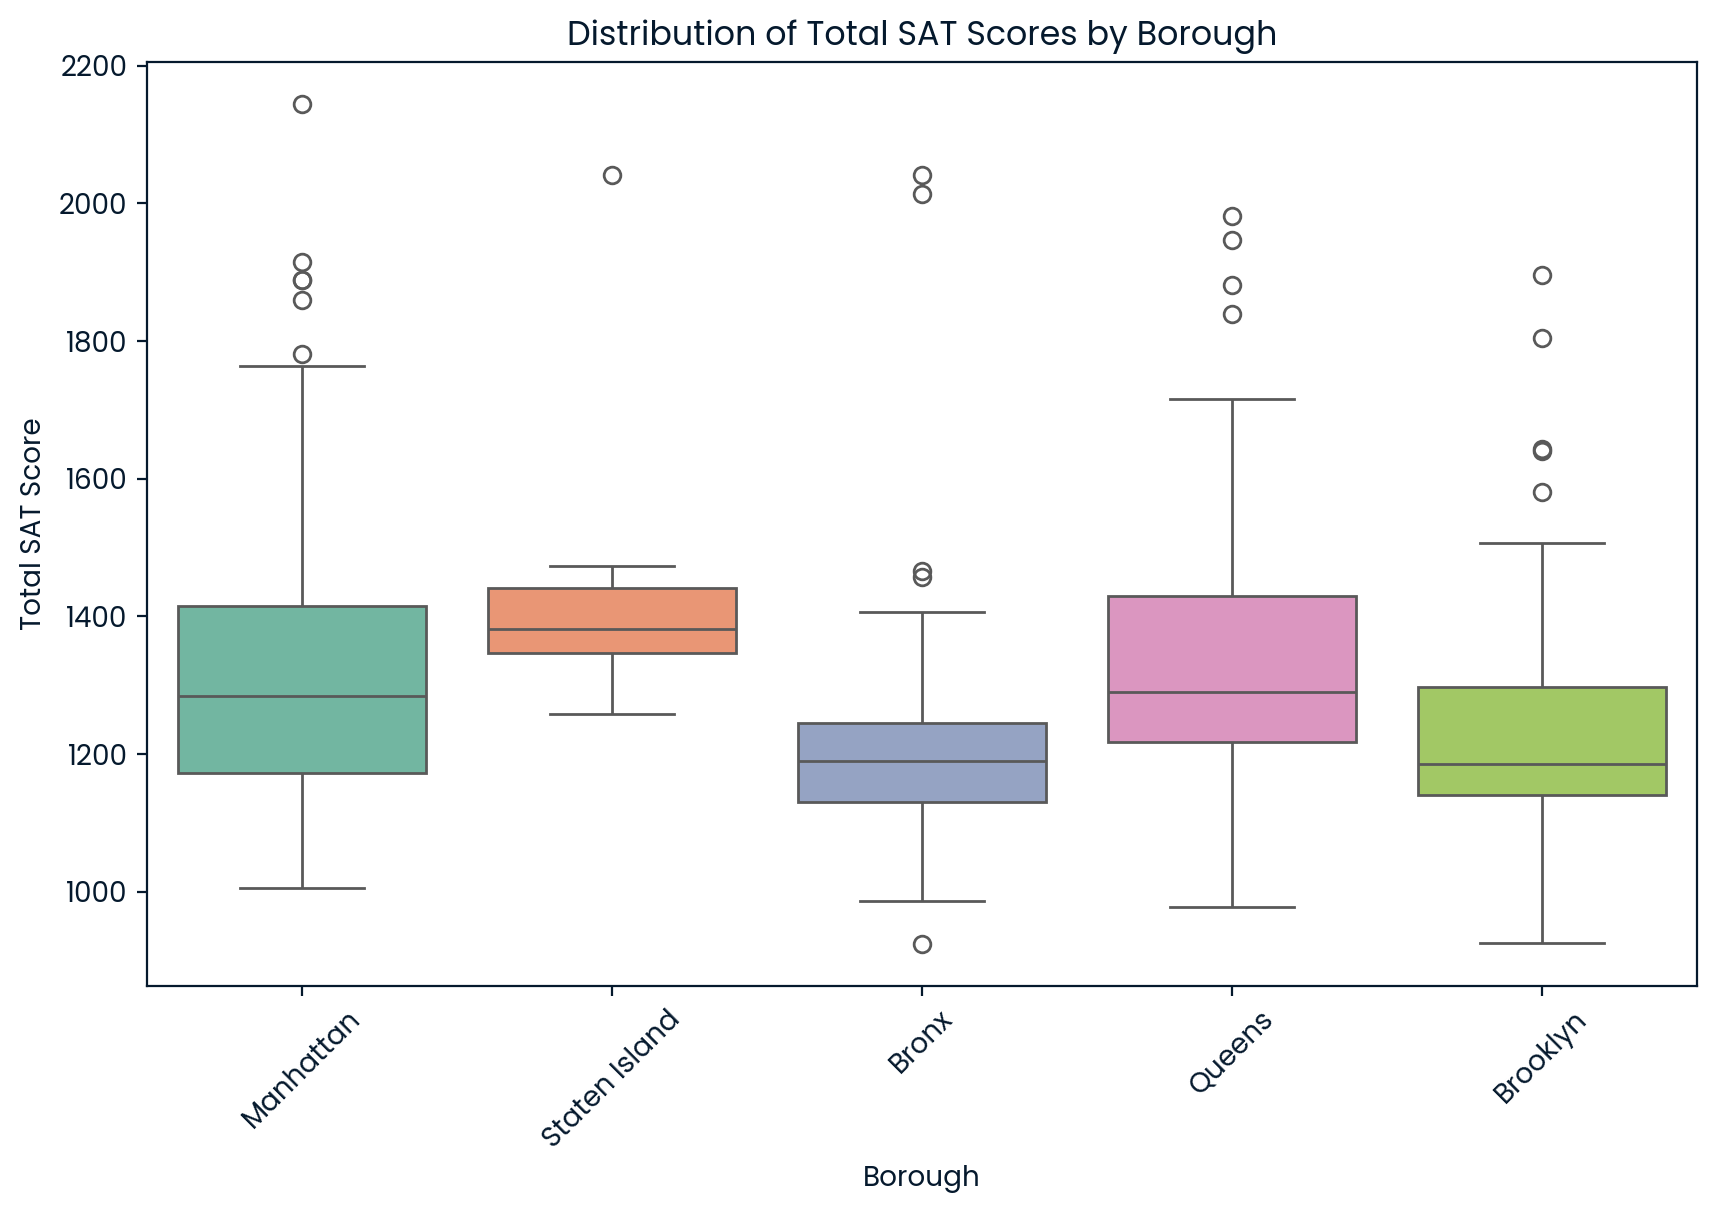

--- SAT Score Boundaries ---
     average_math  average_reading  average_writing  total_SAT
min         317.0            302.0            284.0      924.0
max         754.0            697.0            693.0     2144.0

--- Cross-Section Correlation Matrix ---
                 average_math  average_reading  average_writing
average_math            1.000            0.928            0.934
average_reading         0.928            1.000            0.985
average_writing         0.934            0.985            1.000


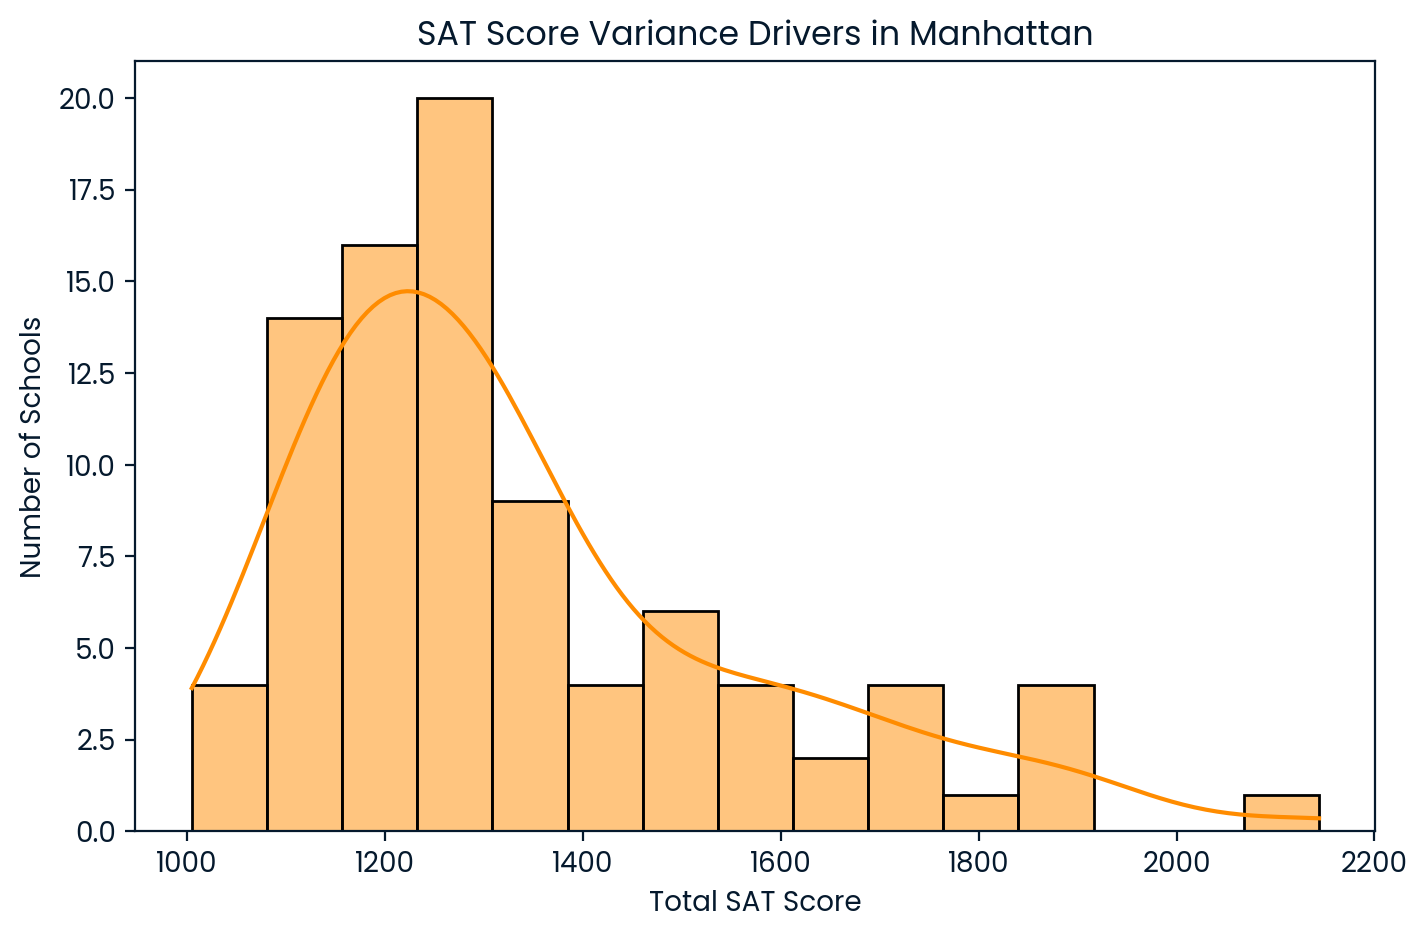

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Read in the data
schools = pd.read_csv("schools.csv")

# Preview the data
schools.head()
best_math_schools =schools[schools['average_math']>=800*0.8]
best_math_schools = best_math_schools[['school_name','average_math']].sort_values('average_math',ascending=False)
print(best_math_schools)

schools['total_SAT'] = schools['average_math'] + schools['average_reading']+ schools['average_writing']
top_10_schools = schools[["school_name","total_SAT"]].sort_values("total_SAT", ascending = False).head(10)

# Display the result
print(top_10_schools)

borough_stats = schools.groupby('borough')['total_SAT'].agg(['count','mean','std']).round(2)

borough_stats.columns = ["num_schools", "average_SAT", "std_SAT"]
largest_std_dev = borough_stats[borough_stats['std_SAT']== borough_stats['std_SAT'].max()]
print(largest_std_dev)

'''Correlation Between Math and Reading
 The relationship between math and reading performance. Adding a trendline helps determine if schools excelling in quantitative skills also excel in literacy.'''
plt.figure(figsize=(8, 6))
sns.regplot(data=schools, x='average_math', y='average_reading', 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Correlation: Average Math vs. Average Reading Scores')
plt.xlabel('Average Math Score')
plt.ylabel('Average Reading Score')
plt.show()

#Visualizing the Top 10 Schools
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_schools, x='total_SAT', y='school_name', palette='crest')
plt.title('Top 10 NYC Public Schools by Total SAT Score')
plt.xlabel('Total SAT Score')
plt.ylabel('') # Removes redundant axis label
plt.xlim(1500, 2400) # Assumes the 2400 max score scale
plt.show()


'''SAT Score Distribution by Borough
The spread, central tendency, and outliers of total SAT scores across NYC boroughs. Whether a borough's high average is driven by a few elite schools or consistent overall performance.'''

plt.figure(figsize=(10, 6))
sns.boxplot(data=schools, x='borough', y='total_SAT', palette='Set2')
plt.title('Distribution of Total SAT Scores by Borough')
plt.xlabel('Borough')
plt.ylabel('Total SAT Score')
plt.xticks(rotation=45)
plt.show()

# Check statistical summaries for score boundaries
score_cols = ['average_math', 'average_reading', 'average_writing', 'total_SAT']
print("--- SAT Score Boundaries ---")
print(schools[score_cols].describe().loc[['min', 'max']])

# Calculate correlation matrix between the three sections
print("\n--- Cross-Section Correlation Matrix ---")
correlation_matrix = schools[['average_math', 'average_reading', 'average_writing']].corr()
print(correlation_matrix.round(3))


# Extracting the name of the borough with the largest standard deviation
top_var_borough = largest_std_dev.index[0] 

# Filter data for just that borough
borough_data = schools[schools['borough'] == top_var_borough]

# Plot the distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=borough_data, x='total_SAT', kde=True, bins=15, color='darkorange')
plt.title(f'SAT Score Variance Drivers in {top_var_borough}')
plt.xlabel('Total SAT Score')
plt.ylabel('Number of Schools')
plt.show()